# Parte 1 — Importação e Preparação dos Dados

In [3]:
#Para saber destino das instalações das bibliotecas
import sys
print(sys.executable)

C:\Users\yeong\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe


In [5]:
#Definindo pastas para salvas tabelas e gráficos
import os

# Definindo os caminhos relativos para salvar os resultados
PASTA_GRAFICOS = '../outputs/graphs/'
PASTA_TABELAS = '../outputs/tables/'

# Garantindo que as pastas existem
os.makedirs(PASTA_GRAFICOS, exist_ok=True)
os.makedirs(PASTA_TABELAS, exist_ok=True)

In [6]:
# Instalando bibliotecas
import sys
!{sys.executable} -m pip install pandas openpyxl matplotlib seaborn numpy scipy

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\yeong\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Carregando arquivo
df = pd.read_excel(r'..\data\Plano De Saúde Database.xlsx', sheet_name='Dados')

# Checando primeiras linhas
df.head()

,Idade,IMC,Qte_Filhos,Fumante,Região,Custo_Saude,Sexo
0,19,27.900,0,Sim,Centro,1688.492400,Feminino
1,18,33.770,1,Não,Sudeste,172.555230,Masculino
2,28,33.000,3,Não,Sudeste,444.946200,Masculino
3,33,22.705,0,Não,Norte,2198.447061,Masculino
4,32,28.880,0,Não,Norte,386.685520,Masculino


In [10]:
# Criando coluna Fumante_Boolean para melhor utilização nos dados na análise
df['Fumante_Boolean'] = df['Fumante'].map({'Sim': 1, 'Não': 0})

#Checando
df.head()

,Idade,IMC,Qte_Filhos,Fumante,Região,Custo_Saude,Sexo,Fumante_Boolean
0,19,27.900,0,Sim,Centro,1688.492400,Feminino,1
1,18,33.770,1,Não,Sudeste,172.555230,Masculino,0
2,28,33.000,3,Não,Sudeste,444.946200,Masculino,0
3,33,22.705,0,Não,Norte,2198.447061,Masculino,0
4,32,28.880,0,Não,Norte,386.685520,Masculino,0


In [11]:
#Criando coluna IMC Faixas para melhor utilização dos dados na análise
def classificar_imc(imc):
    if imc < 17:
        return 'Muito abaixo do peso'
    elif imc <= 18.49:
        return 'Abaixo do peso'
    elif imc <= 24.99:
        return 'Peso normal'
    elif imc <= 29.99:
        return 'Acima do peso'
    elif imc <= 34.99:
        return 'Obesidade I'
    elif imc <= 39.99:
        return 'Obesidade II (Severa)'
    else:
        return 'Obesidade III (Mórbida)'

df['IMC Faixas'] = df['IMC'].apply(classificar_imc)

#Checando
df.head()


,Idade,IMC,Qte_Filhos,Fumante,Região,Custo_Saude,Sexo,Fumante_Boolean,IMC Faixas
0,19,27.900,0,Sim,Centro,1688.492400,Feminino,1,Acima do peso
1,18,33.770,1,Não,Sudeste,172.555230,Masculino,0,Obesidade I
2,28,33.000,3,Não,Sudeste,444.946200,Masculino,0,Obesidade I
3,33,22.705,0,Não,Norte,2198.447061,Masculino,0,Peso normal
4,32,28.880,0,Não,Norte,386.685520,Masculino,0,Acima do peso


Para melhor aproveitar as informações disponibilizadas, era necessário criar duas novas colunas:
- Fumante_Boolean, para que fosse possível contabilizar o número de fumantes e realizar as operações adequadas
- IMC Faixas, para dividir em grupos os funcionários, e assim obter gráficos mais legíveis

A tabela de faixas de IMC utilizada foi a adotada pela OMS, disponível em https://calculacentro.com/calculadora/imc

# Parte 2 — Análise Exploratória

### Tabelas de Frequência (variáveis categóricas)
#### Tabela de frequência para Sexo

In [12]:
# Criando tabela de frequência para a variável Sexo
freq_sexo = df['Sexo'].value_counts().reset_index()
freq_sexo.columns = ['Sexo', 'Freq Absoluta']
# Ordenando resultados do menor pro maior
freq_sexo = freq_sexo.sort_values(by='Freq Absoluta', ascending=True)
freq_sexo['Freq Relativa'] = freq_sexo['Freq Absoluta'] / len(df) *100
freq_sexo['Freq Acumulada'] = freq_sexo['Freq Relativa'].cumsum()

# Salvando resultados na pasta de tabelas
freq_sexo.to_csv(f'{PASTA_TABELAS}resumo_por_sexo.csv', sep=';', encoding='utf-8-sig')

# Adicionando fundo gradiente para melhor visualização
freq_sexo.style.background_gradient(subset='Freq Acumulada', cmap="BuPu")

,Sexo,Freq Absoluta,Freq Relativa,Freq Acumulada
1,Feminino,662,49.476831,49.476831
0,Masculino,676,50.523169,100.000000


#### Tabela de frequência para Fumante

In [13]:
#Criando tabela de frequência para a variável Fumante
freq_fumante = df['Fumante'].value_counts().reset_index()
freq_fumante.columns = ['Fumante', 'Freq Absoluta']
# Ordenando resultados do menor pro maior
freq_fumante = freq_fumante.sort_values(by='Freq Absoluta', ascending=True)
freq_fumante['Freq Relativa'] = freq_fumante['Freq Absoluta'] / len(df) *100
freq_fumante['Freq Acumulada'] = freq_fumante['Freq Relativa'].cumsum()

# Salvando resultados na pasta de tabelas
freq_fumante.to_csv(f'{PASTA_TABELAS}resumo_por_fumante.csv', sep=';', encoding='utf-8-sig')


# Adicionando fundo gradiente para melhor visualização
freq_fumante.style.background_gradient(subset='Freq Acumulada', cmap="BuPu")

,Fumante,Freq Absoluta,Freq Relativa,Freq Acumulada
1,Sim,274,20.478326,20.478326
0,Não,1064,79.521674,100.000000


#### Tabela de frequência para Região

In [14]:
#Criando tabela de frequência para a variável Região
freq_regiao = df['Região'].value_counts().reset_index()
freq_regiao.columns = ['Região', 'Freq Absoluta']
# Ordenando resultados do menor pro maior
freq_regiao = freq_regiao.sort_values(by='Freq Absoluta', ascending=True)
freq_regiao['Freq Relativa'] = freq_regiao['Freq Absoluta'] / len(df) *100
freq_regiao['Freq Acumulada'] = freq_regiao['Freq Relativa'].cumsum()

# Salvando resultados na pasta de tabelas
freq_regiao.to_csv(f'{PASTA_TABELAS}resumo_por_regiao.csv', sep=';', encoding='utf-8-sig')

# Adicionando fundo gradiente para melhor visualização
freq_regiao.style.background_gradient(subset='Freq Acumulada', cmap="BuPu")

,Região,Freq Absoluta,Freq Relativa,Freq Acumulada
3,Nordeste,324,24.215247,24.215247
1,Centro,325,24.289985,48.505232
2,Norte,325,24.289985,72.795217
0,Sudeste,364,27.204783,100.000000


#### Tabela de frequência para IMC

In [15]:
#Estabelecendo ordem entre as faixas
ordem_imc = ['Muito abaixo do peso', 'Abaixo do peso', 'Peso normal',
             'Acima do peso', 'Obesidade I', 'Obesidade II (Severa)', 'Obesidade III (Mórbida)']

#Criando tabela de frequência para a variável IMC
freq_imc = df['IMC Faixas'].value_counts().reindex(ordem_imc).reset_index()
freq_imc.columns = ['IMC Faixas', 'Freq Absoluta']
freq_imc['Freq Relativa'] = freq_imc['Freq Absoluta'] / len(df) *100
freq_imc['Freq Acumulada'] = freq_imc['Freq Relativa'].cumsum()

# Salvando resultados na pasta de tabelas
freq_imc.to_csv(f'{PASTA_TABELAS}resumo_por_imc.csv', sep=';', encoding='utf-8-sig')

# Adicionando fundo gradiente para melhor visualização
freq_imc.style.background_gradient(subset='Freq Acumulada', cmap="BuPu")

,IMC Faixas,Freq Absoluta,Freq Relativa,Freq Acumulada
0,Muito abaixo do peso,3,0.224215,0.224215
1,Abaixo do peso,17,1.270553,1.494768
2,Peso normal,225,16.816143,18.310912
3,Acima do peso,386,28.849028,47.159940
4,Obesidade I,391,29.222720,76.382661
5,Obesidade II (Severa),224,16.741405,93.124066
6,Obesidade III (Mórbida),92,6.875934,100.000000


### Gráficos e Medidas Descritivas (variáveis numéricas)
#### Histograma, Boxplot e Medidas para Idade

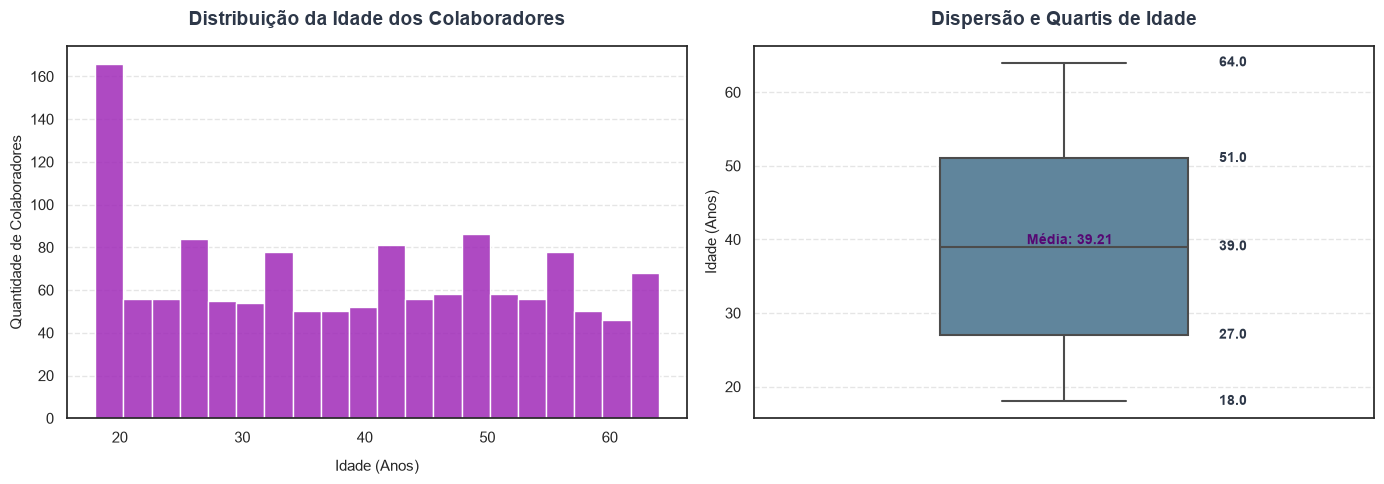

In [53]:
# Criando figura vazia
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')

# Configurando o estilo geral
sns.set_theme(style="white", rc={"axes.grid": False})

# Criando histograma
sns.histplot(df['Idade'], bins=20, ax=axes[0], color="#a02ab8", edgecolor='white', alpha=0.85)
axes[0].set_title('Distribuição da Idade dos Colaboradores', fontsize=14, pad=15, weight='bold', color='#2d3748')
axes[0].set_xlabel('Idade (Anos)', fontsize=11, labelpad=10)
axes[0].set_ylabel('Quantidade de Colaboradores', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Criando boxplot
sns.boxplot(data=df, y='Idade', ax=axes[1], color="#5688A6", width=0.4, linewidth=1.5)
# Cálculo das medidas do boxplot
mediana = df['Idade'].median()
media = df['Idade'].mean()
q1 = df['Idade'].quantile(0.25)
q3 = df['Idade'].quantile(0.75)
minimo = df['Idade'].min()
maximo = df['Idade'].max()
valores = [minimo, q1, mediana, q3, maximo]
# Escrevendo os valores
for val in valores:
    axes[1].text(
        x=0.25,                   # Posição horizontal do texto
        y=val,                    # Posição vertical (a idade)
        s=f'{val:.1f}',           # Formatação do texto
        ha='left',                # Alinhamento horizontal
        va='center',              # Alinhamento vertical 
        fontsize=10,              # Tamanho da fonte
        fontweight='bold',        # Negrito
        color='#2d3748'         # Cor do texto
    )
# Escrevendo o valor da média e deslocando um pouco acima para não atrapalhar a visualização
axes[1].text(
    x=-0.06,                      # Deslocamento horizontal
    y=media + 0.7,                # Deslocamento vertical 
    s=f'Média: {media:.2f}',      # Texto personalizado para diferenciar da mediana
    ha='left', 
    va='center', 
    fontsize=10, 
    fontweight='bold', 
    color="#560873"                  # Cor do texto 
)
axes[1].set_title('Dispersão e Quartis de Idade', fontsize=14, pad=15, weight='bold', color='#2d3748')
axes[1].set_ylabel('Idade (Anos)', fontsize=11)
axes[1].set_xlabel('') # Removendo o texto desnecessário do eixo X
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# Ajustando o espaçamento
plt.tight_layout()

# Salvando com alta qualidade na sua pasta automática
plt.savefig('../outputs/graphs/graficos_idade.png', dpi=300, bbox_inches='tight')
plt.show()

In [36]:
# Calculando as medidas descritivas
medidas_idade = df['Idade'].agg(['mean', 'median', 'std', 'min', 'max']).to_frame()
medidas_idade.columns = ['Estatística']
medidas_idade.index = ['Média', 'Mediana', 'Desvio Padrão', 'Mínimo', 'Máximo']

# Salvando resultados na pasta de tabelas
medidas_idade.to_csv(f'{PASTA_TABELAS}medidas_descritivas_idade.csv', sep=';', encoding='utf-8-sig')

# Formatando e arredondando
medidas_idade.style.format("{:.2f}").set_caption("Medidas Descritivas da Idade")

,Estatística
Média,39.21
Mediana,39.00
Desvio Padrão,14.05
Mínimo,18.00
Máximo,64.00


#### Histograma, Boxplot e Medidas para Quantidade de Filhos

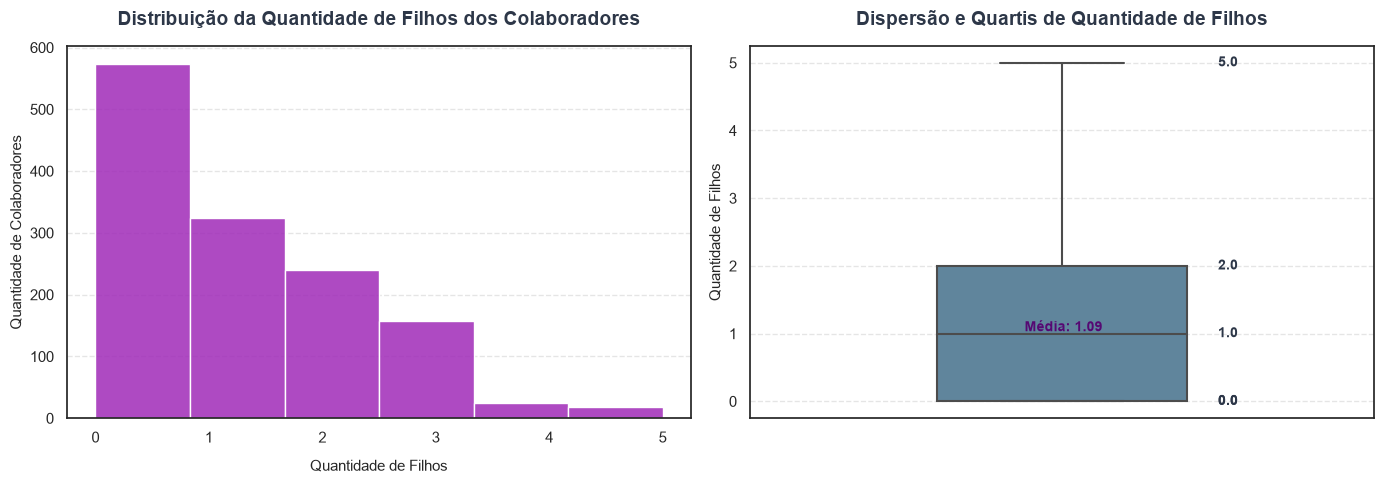

In [54]:
# Criando figura vazia
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')

# Configurando o estilo geral
sns.set_theme(style="white", rc={"axes.grid": False})

# Criando histograma
sns.histplot(df['Qte_Filhos'], bins=6, ax=axes[0], color="#a02ab8", edgecolor='white', alpha=0.85)
axes[0].set_title('Distribuição da Quantidade de Filhos dos Colaboradores', fontsize=14, pad=15, weight='bold', color='#2d3748')
axes[0].set_xlabel('Quantidade de Filhos', fontsize=11, labelpad=10)
axes[0].set_ylabel('Quantidade de Colaboradores', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Criando boxplot
sns.boxplot(data=df, y='Qte_Filhos', ax=axes[1], color="#5688A6", width=0.4, linewidth=1.5)
# Cálculo das medidas do boxplot
mediana = df['Qte_Filhos'].median()
media = df['Qte_Filhos'].mean()
q1 = df['Qte_Filhos'].quantile(0.25)
q3 = df['Qte_Filhos'].quantile(0.75)
minimo = df['Qte_Filhos'].min()
maximo = df['Qte_Filhos'].max()
valores = [minimo, q1, mediana, q3, maximo]
# Escrevendo os valores
for val in valores:
    axes[1].text(
        x=0.25,                   # Posição horizontal do texto
        y=val,                    # Posição vertical (a idade)
        s=f'{val:.1f}',           # Formatação do texto
        ha='left',                # Alinhamento horizontal
        va='center',              # Alinhamento vertical 
        fontsize=10,              # Tamanho da fonte
        fontweight='bold',        # Negrito
        color='#2d3748'         # Cor do texto
    )
# Escrevendo o valor da média e deslocando um pouco acima para não atrapalhar a visualização
axes[1].text(
    x=-0.06,                      # Deslocamento horizontal
    y=media,                      # Deslocamento vertical 
    s=f'Média: {media:.2f}',      # Texto personalizado para diferenciar da mediana
    ha='left', 
    va='center', 
    fontsize=10, 
    fontweight='bold', 
    color="#560873"                  # Cor do texto 
)
axes[1].set_title('Dispersão e Quartis de Quantidade de Filhos', fontsize=14, pad=15, weight='bold', color='#2d3748')
axes[1].set_ylabel('Quantidade de Filhos', fontsize=11)
axes[1].set_xlabel('') # Removendo o texto desnecessário do eixo X
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# Ajustando o espaçamento
plt.tight_layout()

# Salvando com alta qualidade na sua pasta automática
plt.savefig('../outputs/graphs/graficos_quantidade_filhos.png', dpi=300, bbox_inches='tight')
plt.show()

In [55]:
# Calculando as medidas descritivas
medidas_qte_filhos = df['Qte_Filhos'].agg(['mean', 'median', 'std', 'min', 'max']).to_frame()
medidas_qte_filhos.columns = ['Estatística']
medidas_qte_filhos.index = ['Média', 'Mediana', 'Desvio Padrão', 'Mínimo', 'Máximo']

# Salvando resultados na pasta de tabelas
medidas_qte_filhos.to_csv(f'{PASTA_TABELAS}medidas_descritivas_qte_filhos.csv', sep=';', encoding='utf-8-sig')

# Formatando e arredondando
medidas_qte_filhos.style.format("{:.2f}").set_caption("Medidas Descritivas da Quantidade de Filhos")

,Estatística
Média,1.09
Mediana,1.00
Desvio Padrão,1.21
Mínimo,0.00
Máximo,5.00


#### Histograma, Boxplot e Medidas para Custos com Saúde

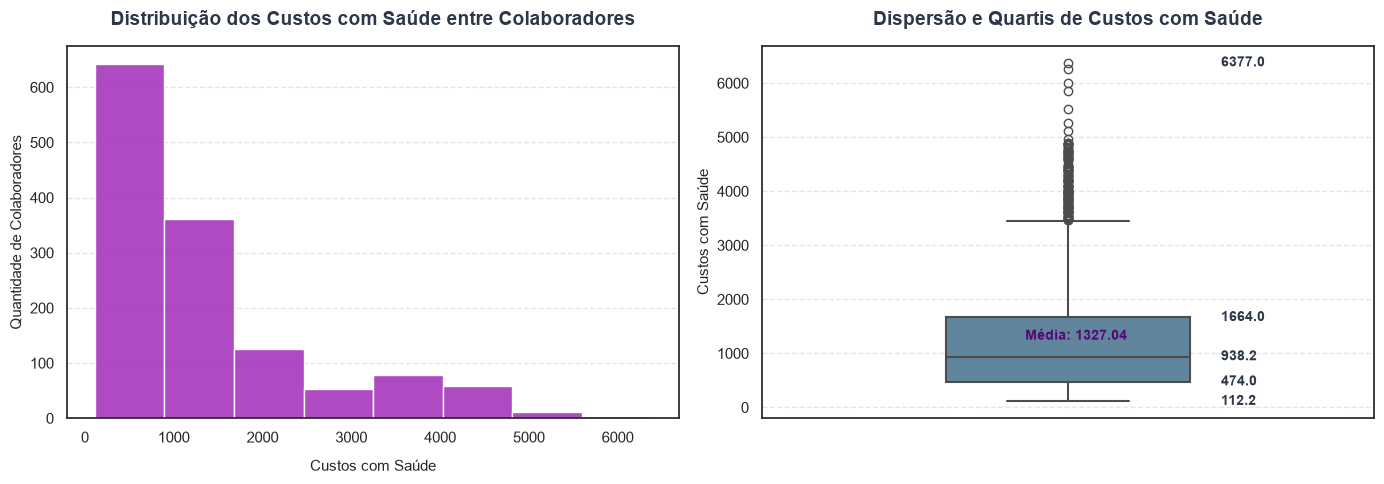

In [75]:
# Criando figura vazia
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')

# Configurando o estilo geral
sns.set_theme(style="white", rc={"axes.grid": False})

# Criando histograma
sns.histplot(df['Custo_Saude'], bins=8, ax=axes[0], color="#a02ab8", edgecolor='white', alpha=0.85)
axes[0].set_title('Distribuição dos Custos com Saúde entre Colaboradores', fontsize=14, pad=15, weight='bold', color='#2d3748')
axes[0].set_xlabel('Custos com Saúde', fontsize=11, labelpad=10)
axes[0].set_ylabel('Quantidade de Colaboradores', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Criando boxplot
sns.boxplot(data=df, y='Custo_Saude', ax=axes[1], color="#5688A6", width=0.4, linewidth=1.5)
# Cálculo das medidas do boxplot
mediana = df['Custo_Saude'].median()
media = df['Custo_Saude'].mean()
q1 = df['Custo_Saude'].quantile(0.25)
q3 = df['Custo_Saude'].quantile(0.75)
minimo = df['Custo_Saude'].min()
maximo = df['Custo_Saude'].max()
valores = [minimo, q1, mediana, q3, maximo]
# Escrevendo os valores
for val in valores:
    axes[1].text(
        x=0.25,                   # Posição horizontal do texto
        y=val,                    # Posição vertical (a idade)
        s=f'{val:.1f}',           # Formatação do texto
        ha='left',                # Alinhamento horizontal
        va='center',              # Alinhamento vertical 
        fontsize=10,              # Tamanho da fonte
        fontweight='bold',        # Negrito
        color='#2d3748'         # Cor do texto
    )
# Escrevendo o valor da média e deslocando um pouco acima para não atrapalhar a visualização
axes[1].text(
    x=-0.07,                      # Deslocamento horizontal
    y=media,                      # Deslocamento vertical 
    s=f'Média: {media:.2f}',      # Texto personalizado para diferenciar da mediana
    ha='left', 
    va='center', 
    fontsize=10, 
    fontweight='bold', 
    color="#560873"                  # Cor do texto 
)
axes[1].set_title('Dispersão e Quartis de Custos com Saúde', fontsize=14, pad=15, weight='bold', color='#2d3748')
axes[1].set_ylabel('Custos com Saúde', fontsize=11)
axes[1].set_xlabel('') # Removendo o texto desnecessário do eixo X
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# Ajustando o espaçamento
plt.tight_layout()

# Salvando com alta qualidade na sua pasta automática
plt.savefig('../outputs/graphs/graficos_custos_saude.png', dpi=300, bbox_inches='tight')
plt.show()

In [76]:
# Calculando as medidas descritivas
medidas_custo_saude = df['Custo_Saude'].agg(['mean', 'median', 'std', 'min', 'max']).to_frame()
medidas_custo_saude.columns = ['Estatística']
medidas_custo_saude.index = ['Média', 'Mediana', 'Desvio Padrão', 'Mínimo', 'Máximo']

# Salvando resultados na pasta de tabelas
medidas_custo_saude.to_csv(f'{PASTA_TABELAS}medidas_descritivas_custo_saude.csv', sep=';', encoding='utf-8-sig')

# Formatando e arredondando
medidas_custo_saude.style.format("{:.2f}").set_caption("Medidas Descritivas dos Custos com Saúde")

,Estatística
Média,1327.04
Mediana,938.20
Desvio Padrão,1211.00
Mínimo,112.19
Máximo,6377.04


### Tabelas Dinâmicas Bivariadas

In [93]:
# Criando função reutilizável para tabelas dinâmicas
def tabela_bivariada(df, coluna):
    tabela = df.groupby(coluna).agg(
        Freq_Absoluta=(coluna, 'count'),
        Soma_Custos=('Custo_Saude', 'sum')
    ).reset_index()
    
    # Criando a linha de Total Geral (Cálculos dos totais)
    total_freq = tabela['Freq_Absoluta'].sum()
    total_custos = tabela['Soma_Custos'].sum()

    # Calculando tabelas
    tabela['Freq_Relativa'] = tabela['Soma_Custos'] / tabela['Soma_Custos'].sum()
    tabela['Gasto_Por_Colaborador'] = tabela['Soma_Custos'] / tabela['Freq_Absoluta']
    
    #Criando linhas de total geral 
    linha_total = pd.DataFrame([{
        coluna: 'Total Geral',
        'Freq_Absoluta': total_freq,
        'Soma_Custos': total_custos,
        'Freq_Relativa': 1.0,              
        'Gasto_Por_Colaborador': None       
    }])

    # Unindo as categorias com a linha de Total Geral no final
    tabela = pd.concat([tabela, linha_total], ignore_index=True)

    # Limpa o Gasto por Colaborador do Total Geral
    tabela.loc[tabela[coluna] == 'Total Geral', 'Gasto_Por_Colaborador'] = None
    
    # Renomeando coluna
    tabela.columns = [coluna.capitalize(), 'Frequência Absoluta', 'Custo Total', 'Frequência Relativa', 'Gasto por Colaborador']

    # Salvando como CSV
    # O nome do arquivo muda dinamicamente dependendo da coluna
    nome_arquivo = f'{PASTA_TABELAS}resumo_custo_por_{coluna.lower()}.csv'
    tabela.to_csv(nome_arquivo, sep=';', index=False, encoding='utf-8-sig')

    # Estilização da tabela
    tabela_estilizada = (tabela.style
        .format({
            'Frequência Absoluta': '{:,}',             # Separador de milhares
            'Frequência Relativa': '{:.2%}',           # Acréscimo de símbolo de porcentagem
            'Custo Total': 'R$ {:,.2f}',               # Formatando para moeda real 
            'Gasto por Colaborador': lambda x: f'R$ {x:,.2f}' if pd.notnull(x) else '' # Só formata se não for nulo
        })
        .hide(axis='index')                            # Escondendo coluna de índices
        .hide(subset=['Frequência Absoluta'], axis='columns') # Escondendo coluna de Frequência Absoluta pois já tem na Tabela de Frequência de Sexo
        .set_properties(**{'text-align': 'center'})    # Centralizando texto
        .background_gradient(cmap='BuPu', subset=['Gasto por Colaborador']) # Cor
    )
    
    return tabela_estilizada

tabela_bivariada(df, 'Sexo')

Sexo,Custo Total,Frequência Relativa,Gasto por Colaborador
Feminino,"R$ 832,106.12",46.86%,"R$ 1,256.96"
Masculino,"R$ 943,476.38",53.14%,"R$ 1,395.68"
Total Geral,"R$ 1,775,582.50",100.00%,


In [90]:
tabela_bivariada(df, 'Fumante_Boolean')

Fumante_boolean,Frequência Absoluta,Custo Total,Frequência Relativa,Gasto por Colaborador
0,"1,064","R$ 897,406.15",25.27%,R$ 843.43
1,274,"R$ 878,176.35",24.73%,"R$ 3,205.02"
Total Geral,"1,338","R$ 1,775,582.50",50.00%,
